# Introduction to Neural Networks - PyTorch

# Installations

In [3]:
%pip install numpy
%pip install pandas
%pip install matplotlib
%pip install torch
%pip install torchvision
%pip install gradio

# Imports

In [ ]:

import numpy as np
import pandas as pd
import io
import matplotlib.pyplot as plt
from helpers import plot_loss
from PIL import Image
import gradio as gr

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from torchvision import datasets, transforms

## Data Preparation

### Shuffling the Data

In [ ]:

def shuffle_data(features: torch.Tensor, labels: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
    '''
    Shuffle the features and labels of a dataset.
    Returns a tuple of shuffled features and shuffled labels.
    '''
    shuffled_features, shuffled_labels = None, None

    shuffleInd=torch.randperm(features.size(0))
    shuffled_features = features[shuffleInd]
    shuffled_labels = labels[shuffleInd]


    return shuffled_features, shuffled_labels

### Splitting the Data into Training and Testing Sets

In [ ]:

def split_data(features: torch.Tensor, labels: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:

    TRAIN_TEST_SPLIT_RATIO = 0.8
    train_features, train_labels = None, None
    test_features, test_labels = None, None


    split_idx = int(TRAIN_TEST_SPLIT_RATIO * len(features))
    train_features, test_features = torch.split(features, [split_idx, len(features) - split_idx])
    train_labels, test_labels = torch.split(labels, [split_idx, len(labels) - split_idx])

    return train_features, train_labels, test_features, test_labels

### Creating the Dataset and DataLoader

In [ ]:

def create_dataloader(train_features: torch.Tensor, train_labels: torch.Tensor, batch_size: int = 64) -> DataLoader:
    """Creates a DataLoader for the training features and labels."""
    train_loader = None


    training_dataset = TensorDataset(train_features, train_labels)

    train_loader = DataLoader(
        dataset=training_dataset,
        batch_size=batch_size,
        shuffle=True
    )


    return train_loader

## MNIST Digit Classification

### MNIST Introduction

100%|██████████| 9.91M/9.91M [00:00<00:00, 16.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 531kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.48MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.86MB/s]


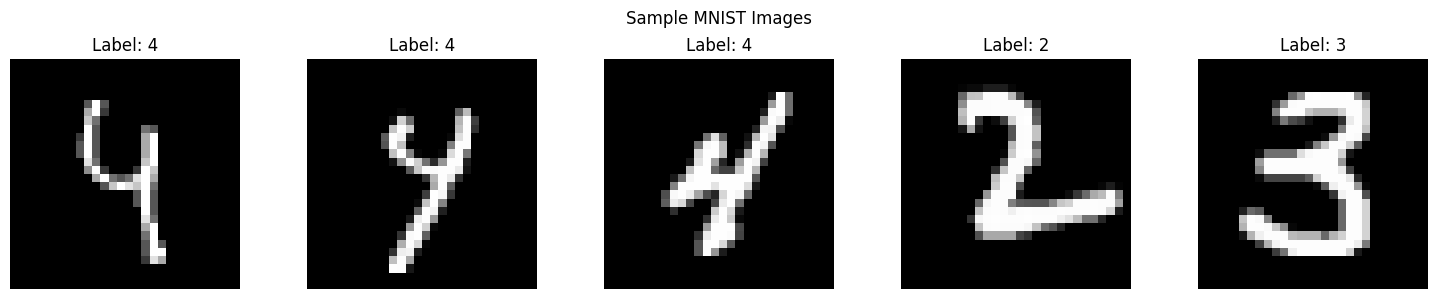

Number of Samples: 60000


In [9]:
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
mnist_dataset = datasets.MNIST('data', train=True, download=True, transform=transform)


sample_indices = np.random.randint(0, len(mnist_dataset), size=5)
fig, axs = plt.subplots(1, 5, figsize=(15, 3))
fig.suptitle('Sample MNIST Images')
for i, idx in enumerate(sample_indices):
    image, label = mnist_dataset[idx]
    axs[i].imshow(image.squeeze(), cmap='gray')
    axs[i].set_title(f'Label: {label}')
    axs[i].axis('off')

plt.tight_layout()
plt.show()

images = torch.stack([img for img, _ in mnist_dataset])
labels = torch.tensor([label for _, label in mnist_dataset])

print(f"Number of Samples: {len(images)}")

### Building Your Neural Network to Classify Digits

In [ ]:

# Initialize the layers, criterion, and model with classification objective
class MNISTNeuralNetwork(nn.Module):
    # Define the layers of the model that will be used in the forward pass
    def __init__(self, input_size: int, hidden_size: int, output_size: int) -> None:
        super(MNISTNeuralNetwork, self).__init__()

        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)


    # Construct the forward pass using the defined layers and pass the input x through each layer
    def forward(self, x: torch.Tensor) -> torch.Tensor:

        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)

        return x

### MNIST Hyperparameters

In [ ]:

def set_mnist_hyperparameters() -> None:
    '''
    Sets the hyperparameters for the MNIST model.
    '''
    global EPOCHS, LR, BATCH_SIZE, EVAL_EVERY


    EPOCHS = 30
    LR = 0.6
    BATCH_SIZE = 32
    EVAL_EVERY = 18


In [12]:
set_mnist_hyperparameters()

### MNIST PyTorch Training Loop

In [ ]:

def train_model_pytorch_mnist(images, labels, plot_losses=True):
    train_losses = []
    val_losses = []

    input_size = 784

    hidden_size = 128
    output_size = 10

    model = MNISTNeuralNetwork(input_size, hidden_size, output_size)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    EPOCHS = 100
    EVAL_EVERY = 5
    BATCH_SIZE = 64

    # Create DataLoaders
    images, labels = shuffle_data(images, labels)
    train_features, train_labels, test_features, test_labels = split_data(
        images, labels
    )
    train_loader = create_dataloader(train_features, train_labels, batch_size=BATCH_SIZE)
    test_loader = create_dataloader(test_features, test_labels, batch_size=BATCH_SIZE)

    for epoch in range(EPOCHS + 1):
        model.train()
        total_train_loss = 0
        """
        Implement the training loop steps:
        1. Forward pass through the model
        2. Calculate loss
        3. Zero gradients
        4. Backward pass
        5. Update parameters
        """
        for batch_features, batch_labels in train_loader:

            batch_features = batch_features.view(batch_features.size(0), -1)
            optimizer.zero_grad()
            outputs = model(batch_features)
            loss = criterion(outputs, batch_labels)
            loss.backward()
            optimizer.step()


            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Evaluate on validation set every EVAL_EVERY epochs
        if epoch % EVAL_EVERY == 0:
            model.eval()
            total_val_loss = 0
            total_correct = 0

            """
            Implement the evaluation loop steps:
            1. Forward pass through the model (no need for gradients)
            2. Calculate loss
            3. Get predictions and compare with true labels
            """
            with torch.no_grad():
                for batch_features, batch_labels in test_loader:

                    batch_features = batch_features.view(batch_features.size(0), -1)
                    outputs = model(batch_features)

                    loss = criterion(outputs, batch_labels)
                    total_val_loss += loss.item()

                    _, predicted = torch.max(outputs, 1)
                    total_correct += (predicted == batch_labels).sum().item()





            avg_val_loss = total_val_loss / len(test_loader)
            accuracy = (total_correct / len(test_loader.dataset)) * 100
            val_losses.append(avg_val_loss)

            print(
                f"Epoch {epoch}/{EPOCHS} | "
                f"Train Loss: {avg_train_loss:.4f} | "
                f"Validation Loss: {avg_val_loss:.4f} | "
                f"Accuracy: {accuracy:.2f}%"
            )

            if plot_losses:
                plot_loss(
                    train_losses, val_losses, eval_interval=EVAL_EVERY, dynamic=True
                )

    print(
        f"Final Train Loss: {avg_train_loss:.4f} | "
        f"Final Validation Loss: {avg_val_loss:.4f} | "
        f"Final Accuracy: {accuracy:.2f}%"
    )
    if plot_losses:
        plot_loss(train_losses, val_losses, eval_interval=EVAL_EVERY, dynamic=False)
    return model, train_losses, val_losses

Final Train Loss: 0.0071 | Final Validation Loss: 0.2508 | Final Accuracy: 97.52%


<Figure size 640x480 with 0 Axes>

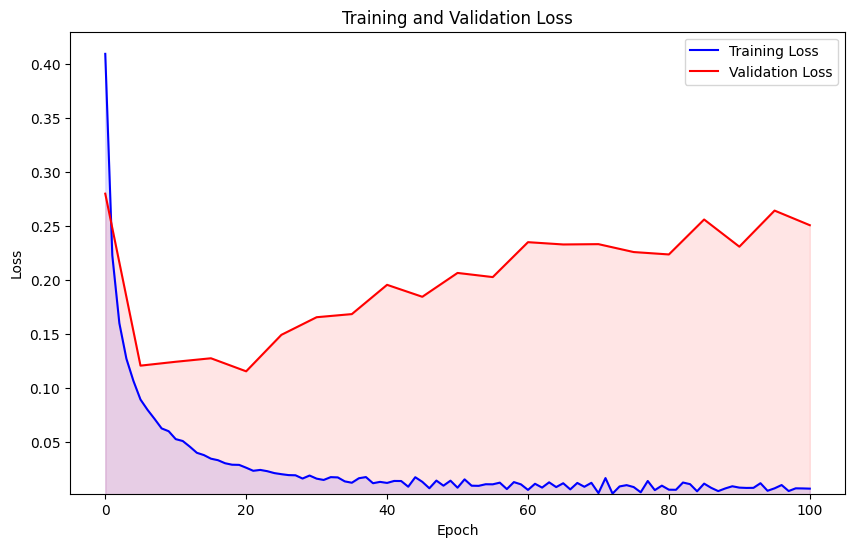

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [14]:
mnist_model, train_losses, val_losses = train_model_pytorch_mnist(images, labels, plot_losses=True)

In [15]:
print(images.shape)
print(labels.shape)

torch.Size([60000, 1, 28, 28])
torch.Size([60000])


In [27]:
mnist_test_dataset = datasets.MNIST('data', train=False, download=True, transform=transform)
test_loader = DataLoader(mnist_test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Number of test samples: {len(test_loader.dataset)}")

total_correct = 0
mnist_model.eval()

with torch.no_grad():
    for test_samples, test_labels in test_loader:
        test_outputs = mnist_model(test_samples)
        predicted_labels = torch.argmax(test_outputs, dim=1)
        total_correct += (predicted_labels == test_labels).sum().item()

accuracy = (total_correct / len(test_loader.dataset)) * 100
print(f'Accuracy: {accuracy:.2f}%')

Number of test samples: 10000
Accuracy: 97.66%
